# Customer Segmentation Using K-Means Clustering

## DevelopersHub Corporation — Advanced Data Science Internship

### Objective
The objective of this project is to segment mall customers based on their spending behavior using unsupervised learning techniques.

### Techniques Used
- Exploratory Data Analysis (EDA)
- K-Means Clustering
- PCA Visualization
- Customer Segmentation Strategy

### Dataset
Mall Customers Dataset

# 1. Importing Required Libraries

In this step, we import libraries required for:
- Data analysis
- Visualization
- Clustering
- Dimensionality reduction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# 2. Loading the Dataset

The dataset contains mall customer information including:
- Gender
- Age
- Annual Income
- Spending Score

In [2]:
df = pd.read_csv("Mall_Customers.csv")

# 3. Previewing the Dataset

We display the first few rows to understand:
- Column names
- Dataset structure
- Feature values

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 4. Dataset Information

This step helps us understand:
- Number of rows and columns
- Data types
- Missing values

## 4.1 Dataset Shape

In [4]:
df.shape


(200, 5)

## 4.2 Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## 4.3 Missing Values Check

We verify whether the dataset contains any missing values.

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# 5. Statistical Summary

This step provides statistical insights about numerical features such as:
- Age
- Annual Income
- Spending Score

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# 6. Exploratory Data Analysis (EDA)

EDA helps us identify patterns and customer behavior trends before clustering.

## 6.1 Gender Distribution

We visualize the number of male and female customers in the dataset.

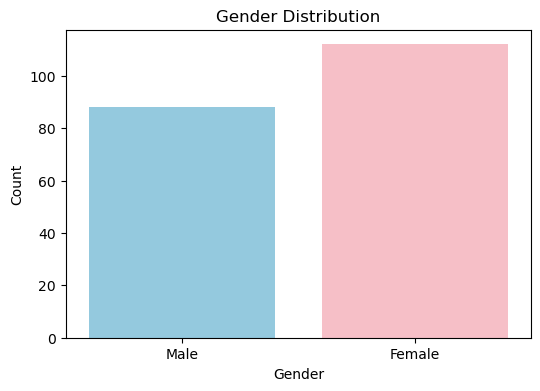

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df,
    palette=['skyblue', 'lightpink']
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## 6.2 Age Distribution

We analyze how customer ages are distributed across the dataset.

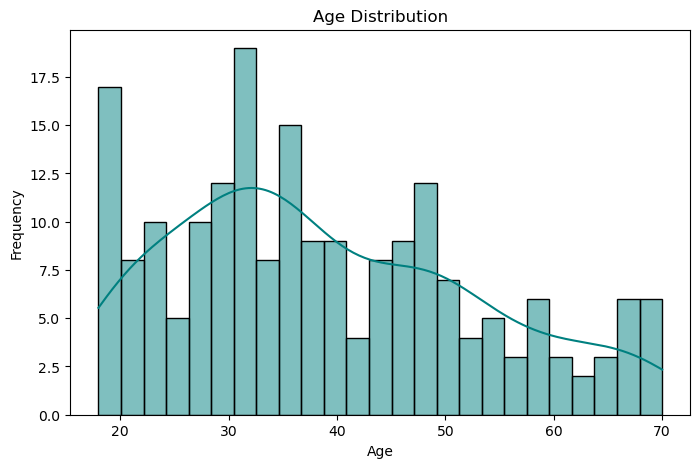

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=25,
    kde=True,
    color='teal'
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## 6.3 Annual Income Distribution

We analyze how customer annual income is distributed across the dataset.

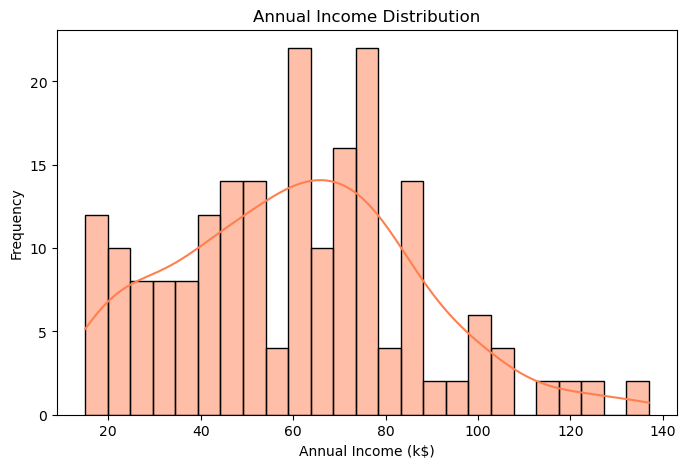

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins=25,
    kde=True,
    color='coral'
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.show()

## 6.4 Spending Score Distribution

Spending Score represents customer purchasing behavior assigned by the mall.

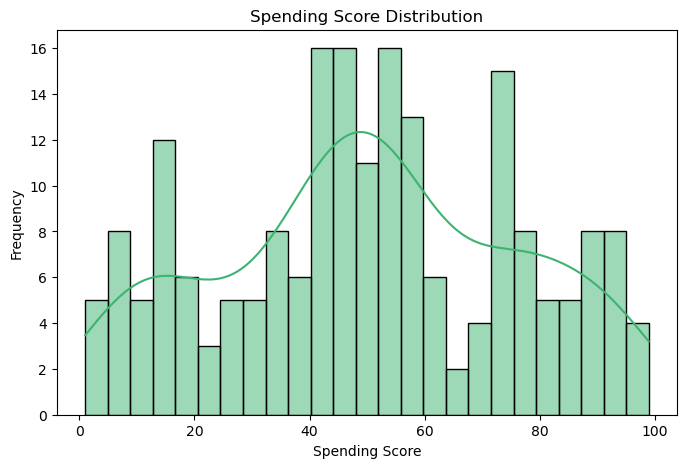

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=25,
    kde=True,
    color='mediumseagreen'
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.show()

## 6.5 Annual Income vs Spending Score

This visualization helps identify natural customer groups based on:
- Income
- Spending behavior

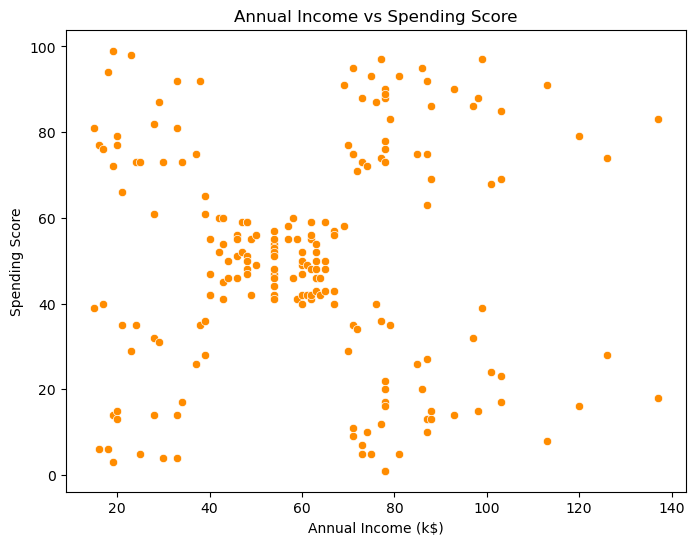

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df,
    color='darkorange'
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

# 7. Data Preprocessing

Before applying K-Means clustering:
- Relevant features are selected
- Numerical features are scaled

Scaling is important because K-Means is distance-based.

## 7.1 Feature Selection

We select:
- Annual Income
- Spending Score

These features are most useful for customer segmentation.

In [14]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## 7.2 Feature Scaling

Feature scaling standardizes the data so that all features contribute equally during clustering.

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 8. Determining Optimal Number of Clusters

The Elbow Method helps identify the optimal number of clusters (`K`) for K-Means clustering.

## 8.1 Elbow Method

We calculate inertia values for different cluster counts.

Inertia measures:
- Within-cluster variation
- Compactness of clusters

In [17]:
inertia = []

In [18]:
for k in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

## 8.2 Elbow Curve Visualization

The optimal number of clusters is usually located at the “elbow point” where inertia starts decreasing more slowly.

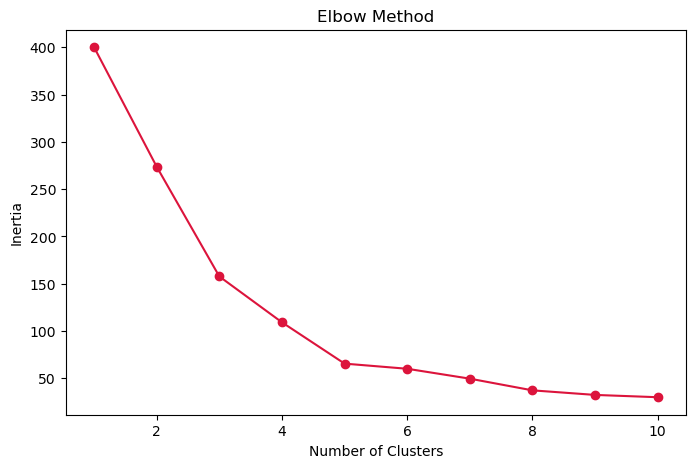

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    inertia,
    marker='o',
    color='crimson'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# 9. Applying K-Means Clustering

Based on the Elbow Method, we select the optimal number of clusters and train the K-Means model.

## 9.1 K-Means Model Training

We use:
- 5 clusters
- random state for reproducibility

In [20]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

In [21]:
clusters = kmeans.fit_predict(X_scaled)

## 9.2 Assigning Cluster Labels

Cluster labels are added to the dataset so each customer belongs to a specific segment.

In [22]:
df['Cluster'] = clusters

## 9.3 Previewing Clustered Data

We inspect the dataset with assigned cluster labels.

In [23]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# 10. Customer Cluster Visualization

We visualize customer segments based on:
- Annual Income
- Spending Score

Each color represents a different customer cluster.

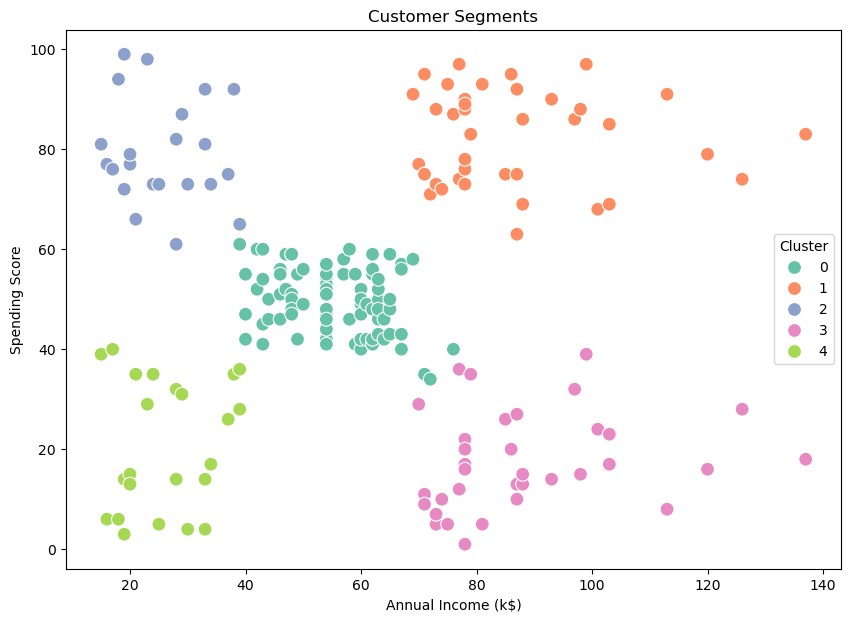

In [24]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set2',
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend(title='Cluster')

plt.show()

# 11. PCA for Cluster Visualization

Principal Component Analysis (PCA) reduces dimensions while preserving important information.

It helps visualize clusters more clearly in 2D space.

## 11.1 Dimensionality Reduction using PCA

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

## 11.2 Creating PCA DataFrame

We create a new dataframe containing:
- Principal Component 1
- Principal Component 2
- Cluster labels

In [27]:
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PC1', 'PC2']
)

In [28]:
pca_df['Cluster'] = clusters

## 11.3 PCA Cluster Visualization

This plot visualizes customer clusters in reduced 2D space using PCA.

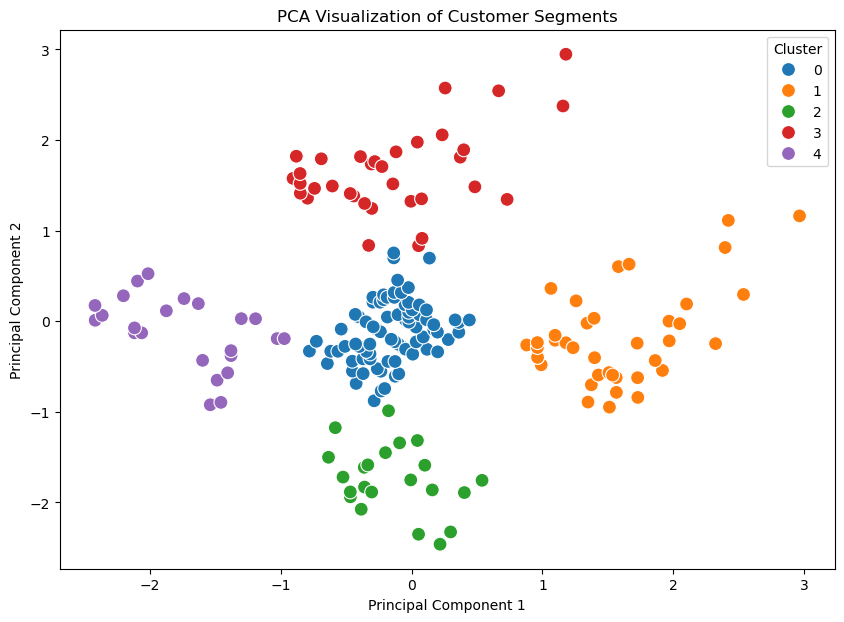

In [29]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='tab10',
    s=100
)

plt.title("PCA Visualization of Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title='Cluster')

plt.show()

# 12. Marketing Strategies for Customer Segments

Based on clustering results, different marketing strategies can be designed for each customer segment.

## Cluster-Based Business Insights

### Cluster 0 — High Income, High Spending
- Premium customers
- Likely to respond to luxury product promotions
- Offer VIP memberships and exclusive rewards

---

### Cluster 1 — Low Income, Low Spending
- Budget-conscious customers
- Focus on discounts and affordable product bundles
- Use price-sensitive marketing campaigns

---

### Cluster 2 — High Income, Low Spending
- Customers with purchasing potential but low engagement
- Encourage spending through loyalty programs and personalized offers

---

### Cluster 3 — Medium Income, Medium Spending
- Balanced customer segment
- Maintain engagement through regular promotions and seasonal campaigns

---

### Cluster 4 — Low Income, High Spending
- High engagement despite lower income
- Promote limited-time offers and trending products carefully
- Avoid overly expensive product targeting

# 13. Conclusion

## Project Summary

This project applied K-Means clustering to segment mall customers based on:
- Annual Income
- Spending Score

The workflow included:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature scaling
- Elbow Method
- K-Means clustering
- PCA visualization
- Business strategy recommendations

---

## Key Findings

- Customers were successfully grouped into distinct behavioral segments.
- Different customer groups exhibited unique spending patterns.
- Income and spending behavior were effective features for segmentation.

---

## Business Impact

Customer segmentation can help businesses:
- Personalize marketing campaigns
- Improve customer engagement
- Increase sales and retention
- Optimize promotional strategies

---

## Final Outcome

The project successfully demonstrated:
- Unsupervised learning using K-Means
- Customer segmentation analysis
- PCA dimensionality reduction
- Business-oriented data interpretation